In [1]:
%load_ext autoreload
import os, sys, json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.config import BASE_CONF, NUM_NODES, ATKS, ALGS, GRAPHS, PERMUTED_GRAPHS, GRAPH_ABBREV, ATK_ABBREV, GLOBAL_SEED, GRAPH_FULL_NAMES
from lib.simulation import load_dataset
from lib.utils import dirichlet_partition, rng
from lib.graph_factory import GraphFactory

In [12]:
# Helper Functions
def get_exp_results(exp_name):
    if(exp_name == 'dsgd_baseline'): algs = ['DSGD']
    else: algs = ALGS
    EXP_DIR = os.path.join(RUN_DIR, exp_name)
    df_complete = pd.read_csv(os.path.join(EXP_DIR, 'sys_sim.csv')).set_index(['graph','attack','alg','k']).sort_index()
    df_metrics = pd.read_csv(os.path.join(EXP_DIR, 'sys_metrics.csv')).set_index(['graph','atk']).sort_index()
    df_clf = pd.read_csv(os.path.join(EXP_DIR, 'clf_metrics.csv')).set_index('graph').sort_index()
    df_ta = pd.read_csv(os.path.join(EXP_DIR, 'test_accuracy.csv'), header=[0,1], index_col=[0,1]).sort_index()
    with open(os.path.join(EXP_DIR, 'config.json')) as f:
        config = json.load(f)
    return dict(sim=df_complete, metrics=df_metrics, clf=df_clf, ta=df_ta, config=config)

convert_str = lambda s: np.array(s[1:-1].split(), dtype=float)

def get_min_test_acc_plots(df_sim, atk):
    fig, ax = plt.subplots(1,1,figsize=(8,4))
    df_tm1_sim = df_sim.loc[pd.IndexSlice[:, atk, :]].xs(slice(-20, None), level='k')
    df_tm1_range = df_tm1_sim.groupby(['graph','alg'])[['min_test_acc','max_test_acc']].agg(['min','max']).unstack('alg')
    df_tm1_range_flat = df_tm1_range.stack('alg', future_stack=True)
    lower = df_tm1_range_flat.xs('min', axis=1, level=1)['min_test_acc']   
    upper = df_tm1_range_flat.xs('max', axis=1, level=1)['max_test_acc']
    lower_pivot = lower.unstack('alg')
    upper_pivot = upper.unstack('alg')
    lower_pivot.index = lower_pivot.index.map(GRAPH_ABBREV)
    upper_pivot.index = upper_pivot.index.map(GRAPH_ABBREV)
    
    span = (upper_pivot - lower_pivot).values.T
    err = np.stack([np.zeros_like(span), span], axis=1)
    lower_pivot.plot(kind='bar', capsize=4, figsize=(10, 5),
                     rot=45, legend=True,
                     color=[COLORS[col] for col in lower_pivot.columns], ax=ax,
                     error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
    ax.set(
        ylim=(0, 0.9),
        xlabel='Graph Type',
        ylabel='Minimum Node-Specific Test Accuracy'
    )
    ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.tight_layout()
    plt.close()
    return fig, ax


In [5]:
# Global Variables
COLORS = dict(zip(ALGS + ['DSGD'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#f0ea46']))
ATK_COLORS = dict(zip(ATKS, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']))
RUN_DIR = Path().resolve()
IMG_DIR = os.path.join(RUN_DIR, 'images')
os.makedirs(IMG_DIR, exist_ok=True)
RESULTS = {d:get_exp_results(d) for d in os.listdir(RUN_DIR)
           if os.path.isdir(os.path.join(RUN_DIR, d)) and d not in {'.ipynb_checkpoints', 'images'}}

In [6]:
sns.set_theme(style="whitegrid")

### Threat Model I (Byzantine-Free) Baseline

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,4))
df_tm1_ta = pd.concat([RESULTS['tm_1_baseline']['ta'].xs('label_flip', level='atk'), RESULTS['dsgd_baseline']['ta'].xs('label_flip', level='atk')], axis=1)
means = df_tm1_ta.xs('mean', axis=1, level=0)
stds  = df_tm1_ta.xs('std', axis=1, level=0)
means.index = means.index.map(GRAPH_ABBREV)
stds.index  = stds.index.map(GRAPH_ABBREV)
means.plot(kind='bar', yerr=stds, capsize=4, figsize=(10, 5), rot=45,
           color=[COLORS[col] for col in means.columns], ax=ax,
           error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
ax.set(
    ylim=(0.85, 0.858),
    xlabel='Graph Type',
    ylabel='Mean Test Accuracy'
)
ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'tm1_base-ta.png'), dpi=300)
plt.show()

Under threat model I, $(b=0)$, RDSGD, the perfect oracle $\mathcal{C}_i^0(\beta=0,\gamma=0)$, and all aggregators attain a test accuracy on the $\pi$-weighted average model $\mathbf{x}_{\pi}^K$ in $[0.852,0.855]$.

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,4))
df_tm1_sim = pd.concat([RESULTS['dsgd_baseline']['sim'].xs(slice(-20, None), level='k').xs('label_flip', level='attack'), 
                        RESULTS['tm_1_baseline']['sim'].xs(slice(-20, None), level='k').xs('label_flip', level='attack')], axis=0)
df_tm1_range = df_tm1_sim.groupby(['graph','alg'])[['min_test_acc','max_test_acc']].agg(['min','max']).unstack('alg')
df_tm1_range_flat = df_tm1_range.stack('alg', future_stack=True)
lower = df_tm1_range_flat.xs('min', axis=1, level=1)['min_test_acc']   
upper = df_tm1_range_flat.xs('max', axis=1, level=1)['max_test_acc']
lower_pivot = lower.unstack('alg')
upper_pivot = upper.unstack('alg')
lower_pivot.index = lower_pivot.index.map(GRAPH_ABBREV)
upper_pivot.index = upper_pivot.index.map(GRAPH_ABBREV)

span = (upper_pivot - lower_pivot).values.T
err = np.stack([np.zeros_like(span), span], axis=1)
lower_pivot.plot(kind='bar', yerr=err, capsize=4, figsize=(10, 5),
                 rot=45, legend=True,
                 color=[COLORS[col] for col in lower_pivot.columns], ax=ax,
                 error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

ax.set(ylim=(0.4, 0.9), xlabel='Graph Type', ylabel='Node-Specific Test Accuracy Range')
ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'tm1_base-ta-range.png'), dpi=300)
fig.show()

Similarly, the range of the inter-node test accuracy is actually tighter for RDSGD, and largest for IOS. 
In Barabasi-Albert graph, few nodes have an extremely high degree, and achieve the maximum test accuracy of approximately 0.85.
However, most nodes have very low degree, and are effectively isolated, and receive less model updates.
Since all $n=20$ nodes are initialized with the same model $\mathbf{x}_0^0=0\forall i\in [n]$, isolated notes with a very low degree
receive less updates than well-connected nodes, and with a deacying step size, this lack of initial communication leads to their models
just not being trained enough.

Since the IOS aggregation rule removes receive model iterates that are furthest from its local model.
Without any byzantine influences and under a near-homogenous data distribution, this leads to a higher mean test accuracy because locally training would already be enough, so including more model iterates from neigbors in the step $k+1$ aggregate actually degrades performance.
However, this benefit is not without a cost.
Across all graphs, IOS and SCC achieve the lowest minimum node-specific test accuracy.
For the Barabasi-Albert graph, a node with a low degree running the IOS aggregation rule would exclude received models from its neighbors, relying more on local gradient descent.

### Threat Model III (Byzantine) Baseline

In [ ]:
df_ta = RESULTS['tm_3_baseline']['ta']
df_sim = RESULTS['tm_3_baseline']['sim']
df_clf = RESULTS['tm_3_baseline']['clf']

In [ ]:
%%capture
df_algs = df_ta['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df_algs.max(axis=1) == df_algs['RDSGD']
display(df_ta[~filt])
print(df_ta['mean'].round(4).to_latex(
    float_format="%.4f",
    label="tab:tm3-base"
))

In [ ]:
%%capture
fig, ax = plt.subplots(1,4,figsize=(12,3))
atk = 'sign_flip'
for i, g in enumerate(['random-regular', 'watts-strogatz', 'erdos-renyi', 'barabasi-albert']):
    ax[i].plot(df_sim.loc[(g, atk, 'RDSGD')]['gamma_k'].ewm(span=30).mean(), color='blue', label='FPR' if i==0 else None)
    ax[i].axhline(y=df_clf.loc[(g), 'gamma_C'], color='blue', ls='--')
    ax[i].plot(df_sim.loc[(g, atk, 'RDSGD')]['beta_k'].ewm(span=30).mean(), color='green', label='FNR' if i==0 else None)
    ax[i].axhline(y=df_clf.loc[(g), 'beta_C'], color='green', ls='--')
    ax[i].set(
        title=f'{GRAPH_ABBREV[g]} Realized Rates',
        xlabel='Iteration (k)',
        yscale='log',
        ylim=(5e-4,1.1)
    )
fig.subplots_adjust(wspace=0.4)
fig.savefig(os.path.join(IMG_DIR, 'tm3-base-realized-rates.png'), dpi=300)
fig.legend()
plt.show()

### High Data Heterogeneity 

In [ ]:
df_ta = RESULTS['high_data_het']['ta']
df_sim = RESULTS['high_data_het']['sim']
df_clf = RESULTS['high_data_het']['clf']

In [ ]:
df_algs = df_ta['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df_algs.max(axis=1) == df_algs['RDSGD']
display(df_algs[~filt])

In [ ]:
fig, ax = get_min_test_acc_plots(df_sim, 'IPM')
display(fig)

### High Byzantine Influence

In [ ]:
df_sim = RESULTS['high_byz']['sim']
df_ta = RESULTS['high_byz']['ta']

In [ ]:
df_algs = df_ta['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df_algs.max(axis=1) == df_algs['RDSGD']
display(df_algs[~filt])

In [ ]:
fig, ax = get_min_test_acc_plots(df_sim, 'IPM')
display(fig)

### Stress Test ($b=8$, $\delta=2$)

In [7]:
df_sim = RESULTS['stress_test']['sim']
df_ta = RESULTS['stress_test']['ta']
df_metrics = RESULTS['stress_test']['metrics']
df_clf = RESULTS['stress_test']['clf']
config = RESULTS['stress_test']['config']

mu = 1
h = config['sys']['num_nodes'] - config['sys']['b']
dp = dirichlet_partition(load_dataset()['y_train'], NUM_NODES, config['data_heterogeneity'], rng('dirichlet_part'))
m = np.min(np.asarray([len(dp[i]) for i in range(NUM_NODES)]))

In [140]:
df_algs = df_ta['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df_algs.max(axis=1) == df_ta[('mean','RDSGD')]
display(df_ta['mean'][filt])
# print(df_ta['mean'].round(4).to_latex(
#     float_format="%.4f",
#     label="tab:tm3-stress-test"
# ))

alg                           CooMed       IOS  ORACLE_0  ORACLE_1     RDSGD  \
graph           atk                                                            
barabasi-albert gaussian    0.409749  0.241403  0.846675  0.843939  0.845931   
                label_flip  0.826130  0.826900  0.846675  0.818658  0.843671   
                sign_flip   0.700693  0.766390  0.846675  0.647247  0.803437   
erdos-renyi     gaussian    0.460121  0.331325  0.845801  0.843723  0.843195   
                label_flip  0.822658  0.837177  0.845801  0.817827  0.841013   
                sign_flip   0.682398  0.757853  0.845801  0.648589  0.839100   
geometric       ALIE        0.840701  0.839091  0.845749  0.842147  0.843126   
                gaussian    0.285143  0.246156  0.845749  0.844831  0.845325   
                label_flip  0.823316  0.835714  0.845749  0.818286  0.842009   
                sign_flip   0.672719  0.792840  0.845749  0.631126  0.833385   
random-regular  ALIE        0.839758  0.835255  0.845385  0.843273  0.845186   
                gaussian    0.253152  0.345351  0.845385  0.843680  0.845706   
                label_flip  0.821810  0.837766  0.845385  0.817065  0.846087   
                sign_flip   0.668952  0.540641  0.845385  0.673550  0.779195   
watts-strogatz  gaussian    0.136719  0.382329  0.844918  0.841117  0.840069   

alg                              SCC   TriMean  
graph           atk                             
barabasi-albert gaussian    0.761056  0.164234  
                label_flip  0.818121  0.826970  
                sign_flip   0.676095  0.728528  
erdos-renyi     gaussian    0.756017  0.403524  
                label_flip  0.817861  0.830753  
                sign_flip   0.686459  0.765082  
geometric       ALIE        0.804130  0.841004  
                gaussian    0.757039  0.252216  
                label_flip  0.818000  0.830623  
                sign_flip   0.669299  0.741766  
random-regular  ALIE        0.841186  0.840710  
                gaussian    0.751628  0.343186  
                label_flip  0.817515  0.831749  
                sign_flip   0.700424  0.771030  
watts-strogatz  gaussian    0.754597  0.152874

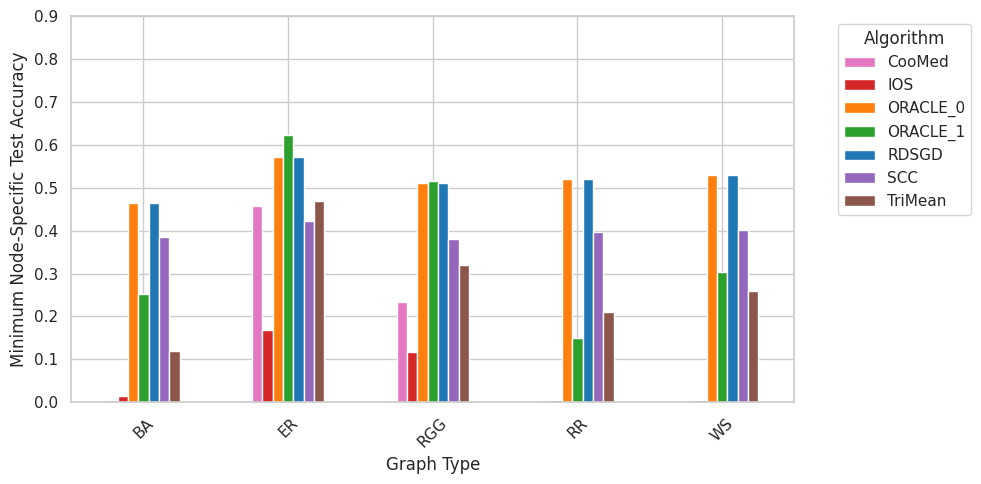

In [13]:
fig, ax = get_min_test_acc_plots(df_sim, 'IPM')
display(fig)

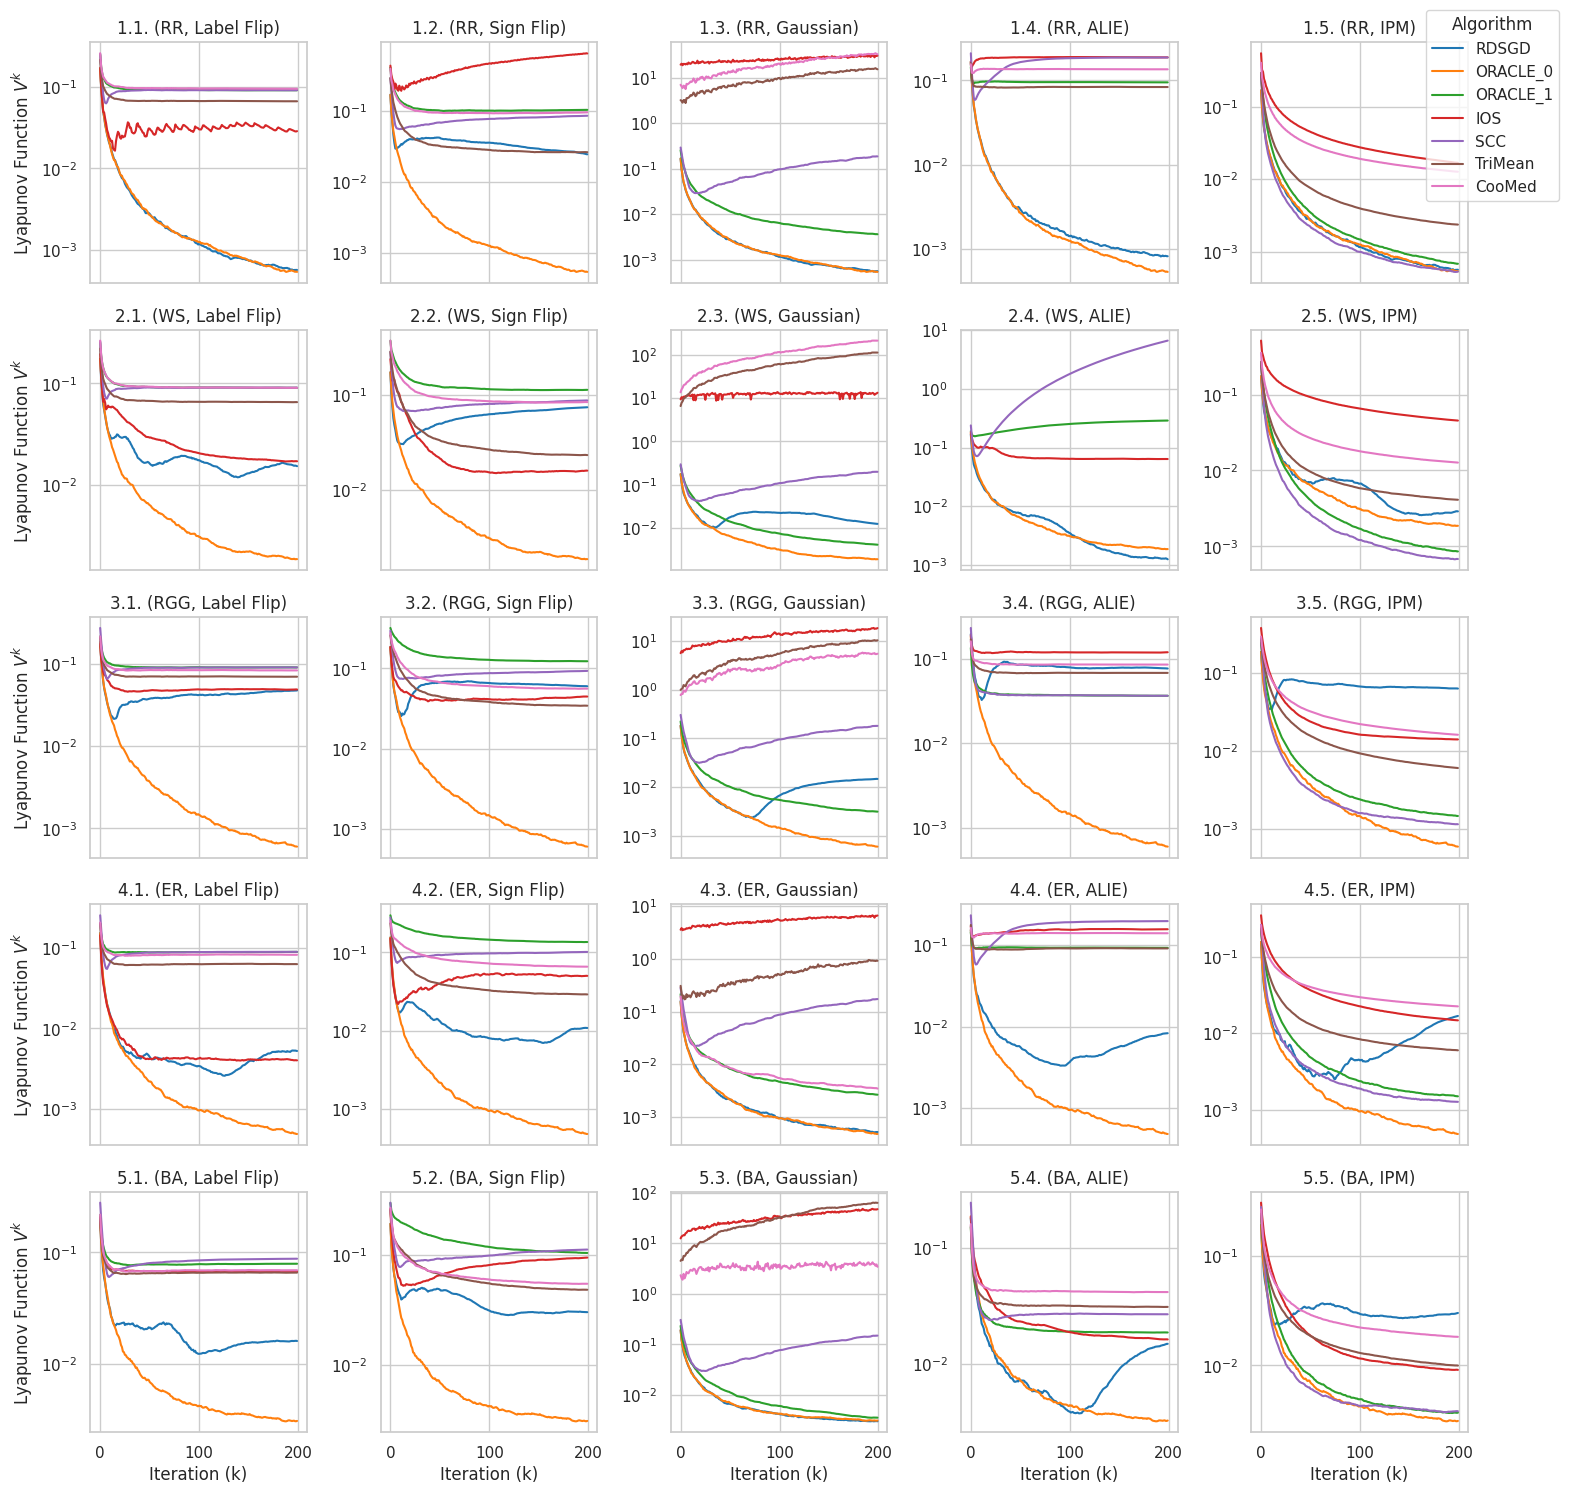

In [11]:
fig1, ax1 = plt.subplots(len(GRAPHS), len(ATKS),
                         figsize=(3 * len(ATKS), 3 * len(GRAPHS)),
                         squeeze=False, sharex=True)

for g_idx, g in enumerate(GRAPHS):
    ax = ax1[g_idx]
    for atk_idx, atk in enumerate(ATKS):
        for alg in ALGS:
            if(g == 'watts-strogatz' and atk=='ALIE' and alg in {'CooMed','TriMean'}): # these plots diverge
                continue
                
            V = df_sim.loc[(g, atk, alg)]['C_unif'] + np.pow(df_sim.loc[(g, atk, alg)]['opt_gap'], 2)
            ax[atk_idx].plot(V, color=COLORS[alg], label=alg if (g_idx == len(GRAPHS)-1 and atk_idx==0) else None)
            
            ax[atk_idx].set(title=f'{g_idx+1}.{atk_idx+1}. ({GRAPH_ABBREV[g]}, {ATK_ABBREV[atk]})', 
                            ylabel="Lyapunov Function $V^{k}$" if atk_idx == 0 else None,
                            xlabel="Iteration (k)" if g_idx == len(GRAPHS)-1 else None,
                            yscale='log')

fig1.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper right')
fig1.tight_layout()

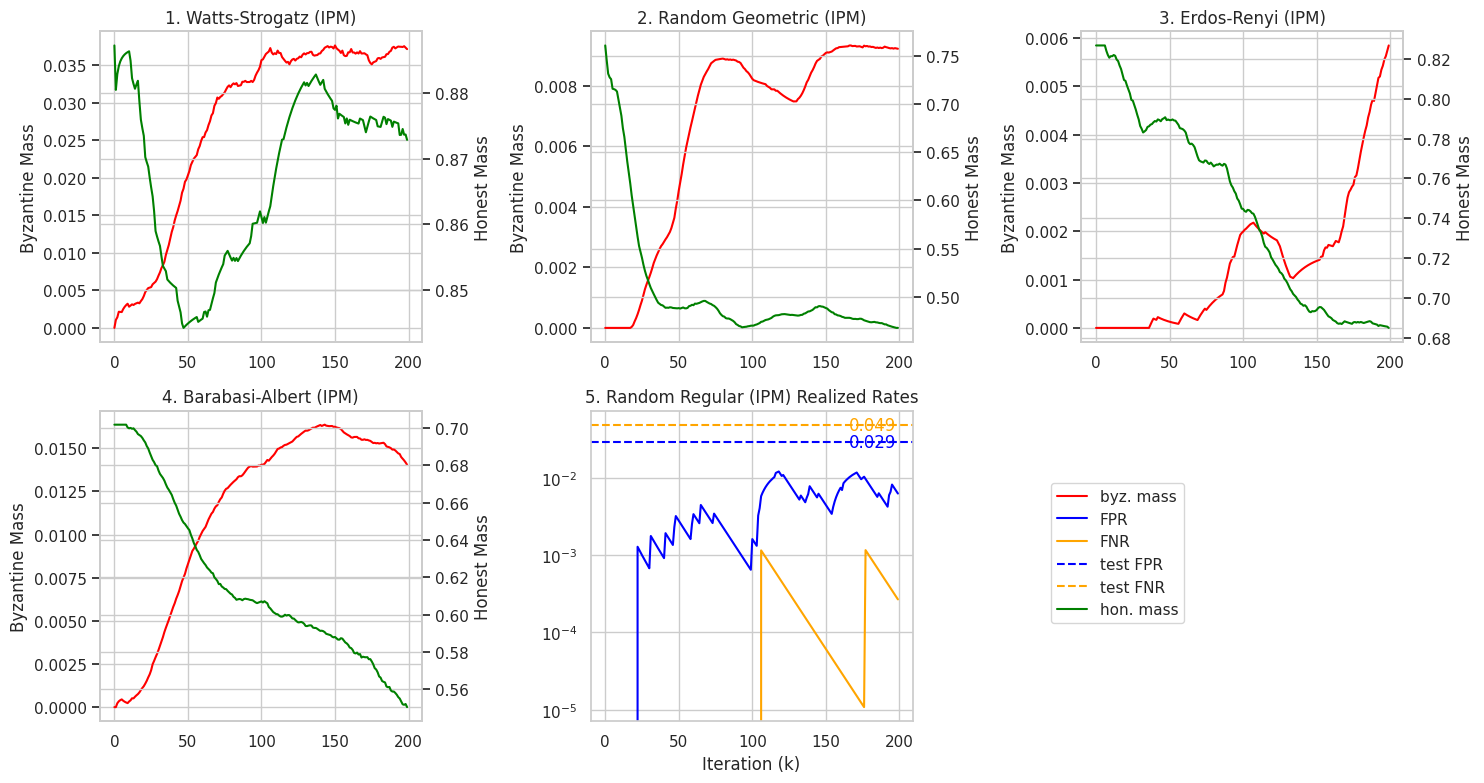

In [144]:
fig1, ax1 = plt.subplots(2,3,figsize=(15,8))
atk = 'IPM'
for g_idx, g in enumerate(['watts-strogatz', 'geometric', 'erdos-renyi', 'barabasi-albert']):
    ax = ax1.flatten()[g_idx]
    if(g == 'random-regular'):
        ax.plot(np.arange(200), df_sim.loc[(g, atk, 'RDSGD')]['byz_w_k'], color='red', marker='.')
        ax2 = ax.twinx()
        ax2.plot(np.arange(200), df_sim.loc[(g, atk, 'RDSGD')]['hon_w_k'], color='green' , marker='.')
        ax2.set_ylabel('Honest Mass')
        ax.set_ylabel('Byzantine Mass')
    else:
        ax.plot(df_sim.loc[(g, atk, 'RDSGD')]['byz_w_k'].ewm(span=30).mean(), label='byz. mass' if g_idx==1 else None, color='red')
        ax2 = ax.twinx()
        ax2.plot(df_sim.loc[(g, atk, 'RDSGD')]['hon_w_k'].ewm(span=30).mean(), label='hon. mass' if g_idx==1 else None, color='green')
        ax2.set_ylabel('Honest Mass')
        ax.set_ylabel('Byzantine Mass')
        ax.set(title=f'{g_idx+1}. {GRAPH_FULL_NAMES[g]} ({atk})')

ax3 = ax1.flatten()[4]
ax3.plot(df_sim.loc[('random-regular', atk, 'RDSGD')]['gamma_k'].ewm(span=30).mean(), color='blue', label='FPR')
ax3.plot(df_sim.loc[('random-regular', atk, 'RDSGD')]['beta_k'].ewm(span=30).mean(),color='orange', label='FNR')

xmin, xmax = ax3.get_xlim()
test_gamma_C = df_clf.loc[('random-regular'), 'gamma_C']
test_beta_C = df_clf.loc[('random-regular'), 'beta_C']

ax3.text(xmax - 0.05 * (xmax - xmin), test_gamma_C, f'{test_gamma_C:.3f}', color='blue', va='center', ha='right')
ax3.axhline(y=test_gamma_C, color='blue', ls='--', label='test FPR')

ax3.text(xmax - 0.05 * (xmax - xmin), test_beta_C, f'{test_beta_C:.3f}', color='orange', va='center', ha='right')
ax3.axhline(y=test_beta_C, color='orange', ls='--', label='test FNR')
ax3.set(yscale= 'log', xlabel='Iteration (k)', title=f"5. Random Regular ({atk}) Realized Rates")

ax1.flatten()[5].set_visible(False)

fig1.subplots_adjust(wspace=1.0, hspace=0.3)
fig1.legend(bbox_to_anchor=(0.8, 0.2), loc='lower right')
fig.savefig(os.path.join(IMG_DIR, 'tm3-stress-test-realized-rates.png'), dpi=300)
fig1.tight_layout()
plt.show()

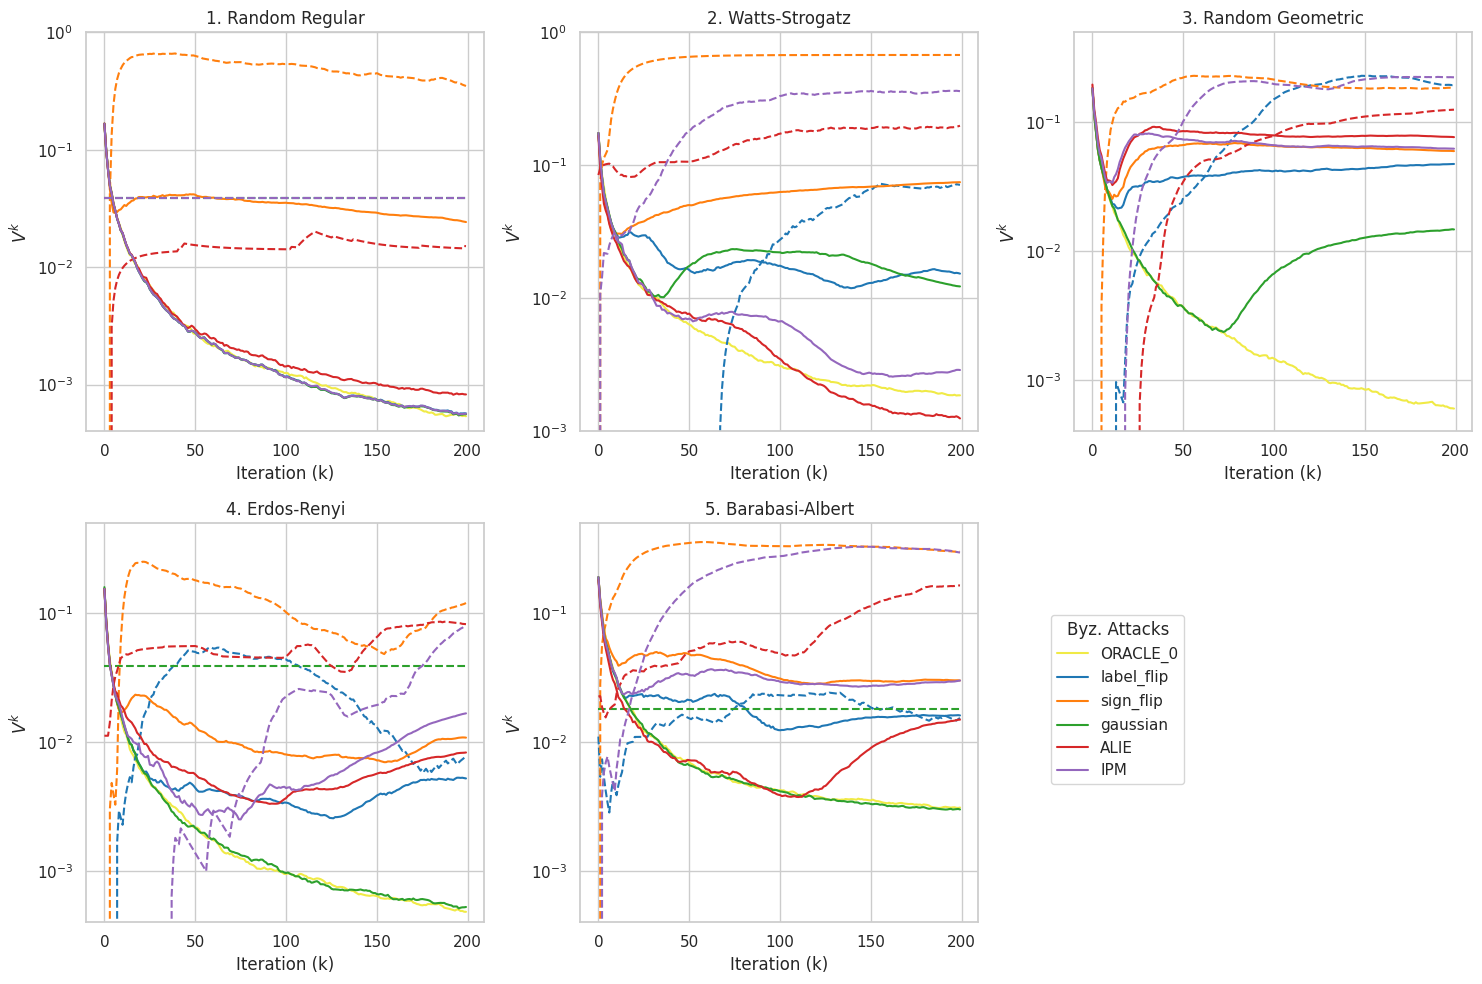

In [87]:
# Lyapunov Convergence and Byzantine Floor
fig1, ax1 = plt.subplots(2,3,figsize=(15,10))
limits = {
    'random-regular':(4e-4,1), 
    'watts-strogatz':(1e-3,1), 
    'geometric':(4e-4,0.5), 
    'erdos-renyi':(4e-4,0.5),
    'barabasi-albert': (4e-4,0.5)
}
for g_idx, g in enumerate(GRAPHS):
    ax = ax1.flatten()[g_idx]
    proj_const = df_clf.loc[(g),'proj_const']
    ax.set(
        title=f'{g_idx+1}. {GRAPH_FULL_NAMES[g]}',
        yscale='log',
        xlabel='Iteration (k)',
        ylabel='$V^k$',
        ylim=limits[g] 
    )
    
    V_ORACLE_0 = df_sim.loc[(g, 'IPM', 'ORACLE_0'), 'C_pi'] + np.pow(df_sim.loc[(g, atk, 'ORACLE_0'),'opt_gap'],2)
    ax.plot(V_ORACLE_0, color='#f0ea46', label='ORACLE_0' if g_idx == 0 else None)

    for atk_idx, atk in enumerate(ATKS):
        V_RDSGD = df_sim.loc[(g, atk, 'RDSGD'), 'C_pi'] + np.pow(df_sim.loc[(g, atk, 'RDSGD'),'opt_gap'],2)

        beta_k = df_sim.loc[(g, atk, 'RDSGD'),'beta_k'].ewm(span=40).mean()
        N_fnr_null = np.sum(df_sim.loc[(g, atk, 'RDSGD'),'beta_k'] < 0.02)
        N_fpr_null = np.sum(df_sim.loc[(g, atk, 'RDSGD'),'gamma_k'] < 0.02)
        if N_fpr_null > 130 and N_fnr_null > 130: # Behavior is like ORACLE_0
            beta_k = np.full(config['sys']['K'], df_clf.loc[(g), 'beta_C'])
        
        dB = df_metrics.loc[(g, atk), 'dB_pi']
        ub = ((proj_const**2) * beta_k * np.pow(dB,2))/(mu**2)
        
        ax.plot(V_RDSGD, color=ATK_COLORS[atk], label=atk if (g_idx == 0) else None)
        ax.plot(ub, ls='--', color=ATK_COLORS[atk])

ax1.flatten()[5].set_visible(False)
fig1.subplots_adjust(wspace=0.4, hspace=0.6)
fig1.legend(bbox_to_anchor=(0.8, 0.2), loc='lower right', title='Byz. Attacks')
fig1.tight_layout()
fig1.savefig(os.path.join(IMG_DIR,'tm-3-stress-test-RDSGD-lyapunov-conv.png'),dpi=300)
plt.show()

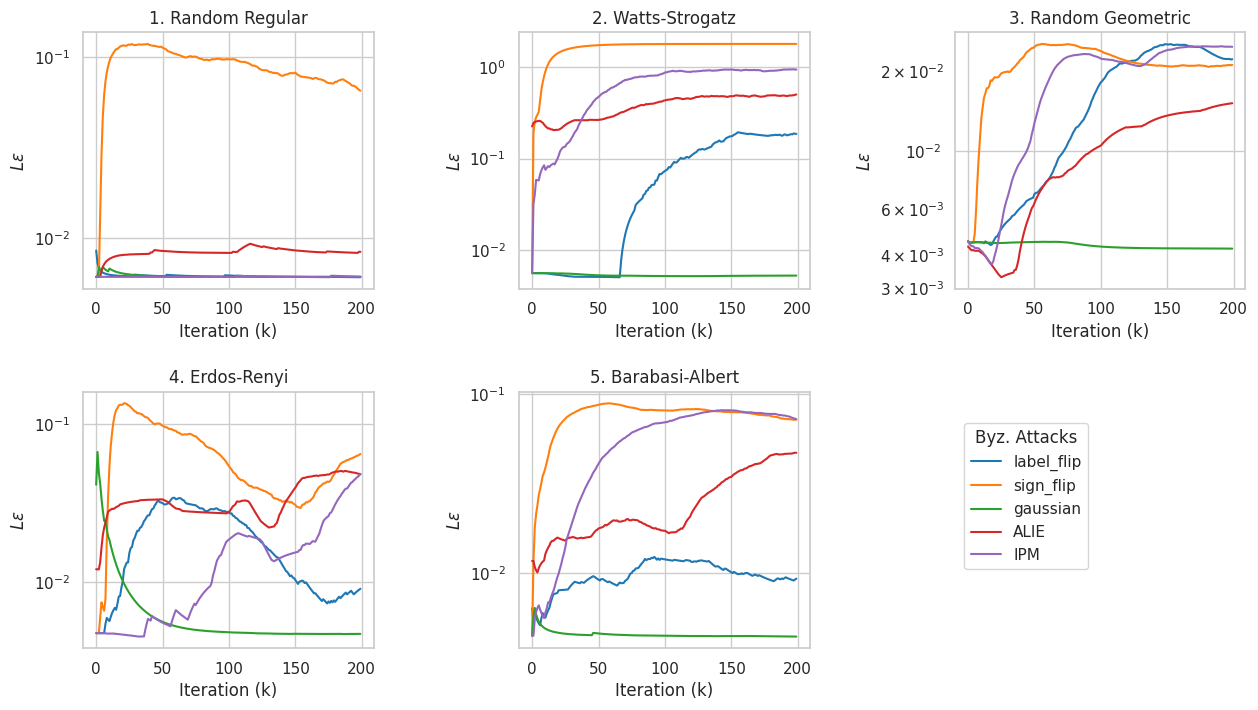

In [108]:
# Generalization Error Upper Bounds
fig, ax = plt.subplots(2,3,figsize=(15,8))
for g_idx, g in enumerate(GRAPHS):
    proj_const = df_clf.loc[(g),'proj_const']
    ax.flatten()[g_idx].set(
        title=f'{g_idx+1}. {GRAPH_FULL_NAMES[g]}',
        yscale='log',
        xlabel='Iteration (k)',
        ylabel='$L\\epsilon$',
    )
    for atk_idx, atk in enumerate(ATKS):
        L = df_metrics.loc[(g,atk),'L']
        x = L * (1-df_clf.loc[g]['gamma_C']) * df_sim.loc[(g,atk,'RDSGD')]['hon_w_k'] * (1/h) 
        y = proj_const * m * df_clf.loc[g]['beta_C'] * df_sim.loc[(g,atk,'RDSGD')]['byz_w_k']
        eps = (4*h * (x + y))/(mu*m)
        ax.flatten()[g_idx].plot(eps.ewm(span=40).mean(), color=ATK_COLORS[atk], label=f"{atk}" if g_idx==1 else None)
        
ax.flatten()[5].set_visible(False)
fig.subplots_adjust(wspace=0.5, hspace=0.4)
fig.legend(bbox_to_anchor=(0.8, 0.2), loc='lower right', title='Byz. Attacks')
plt.show()

### Skewed Edge Weights (weights $\delta=2$)

In [ ]:
df = RESULTS['skewed_edge_weights']['ta']
df1 = df['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df1.max(axis=1) == df1['RDSGD']
display(df1[~filt])

### Worst Case ($b=8$, weights $\delta=2$, data $\delta=2$)

In [ ]:
df = RESULTS['worst_case']['ta']
df1 = df['mean'].drop(columns=['ORACLE_0','ORACLE_1'])
filt = df1.max(axis=1) == df1['RDSGD']
display(df1[~filt])

In [ ]:
df_tm1_sim = RESULTS['worst_case']['sim'].xs(slice(-20, None), level='k')
df_tm1_range = df_tm1_sim.groupby(['graph','alg'])[['min_test_acc','max_test_acc']].agg(['min','max']).unstack('alg')
df_tm1_range_flat = df_tm1_range.stack('alg', future_stack=True)
lower = df_tm1_range_flat.xs('min', axis=1, level=1)['min_test_acc']   
upper = df_tm1_range_flat.xs('max', axis=1, level=1)['max_test_acc']
lower_pivot = lower.unstack('alg')
upper_pivot = upper.unstack('alg')
center = (lower_pivot + upper_pivot) / 2
half   = (upper_pivot - lower_pivot) / 2
center.index = center.index.map(GRAPH_ABBREV)
half.index  = half.index.map(GRAPH_ABBREV)

ax = center.plot(kind='bar', 
                 yerr=half, 
                 capsize=4, 
                 figsize=(10, 5),
                 rot=45, legend=True, 
                 color=[COLORS[col] for col in half.columns],
                 error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
ax.set_ylim(0, 0.9)
ax.set_xlabel('Graph Type')
ax.set_ylabel('Node-Specific Test Accuracy Range')
ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()